In [1]:
# ==========================================
# 1. SETUP ENVIRONMENT & REPRODUCIBILITY
# ==========================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
import joblib
import warnings

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ==========================================
# 2. DATASET LOADING & FEATURE EXTRACTION
# ==========================================
DATA_PATH = "../data/customer_behavior.csv"

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

df = pd.DataFrame()
df['num_helpful'] = pd.to_numeric(df_raw['reviews.numHelpful'], errors='coerce').fillna(0)
df['rating'] = pd.to_numeric(df_raw['reviews.rating'], errors='coerce').fillna(3)
df['customer_review'] = df_raw['reviews.text'].fillna('')

# Biến target
df['target_interest'] = (df['rating'] >= 4).astype(int)

# Giảm mẫu nếu dữ liệu quá lớn để train nhanh
if len(df) > 5000:
    df = df.sample(n=5000, random_state=RANDOM_SEED).reset_index(drop=True)

print("Processed Dataset Shape:", df.shape)
df.head()

Processed Dataset Shape: (5000, 4)


,num_helpful,rating,customer_review,target_interest
0,0.0,5.0,I received this as a gift after my original Ki...,1
1,1.0,4.0,Bought this for easier reading and it meets my...,1
2,0.0,5.0,Alexa does all that was described. It is like ...,1
3,0.0,5.0,I researched about tablets and based on my int...,1
4,0.0,5.0,This is not our first Amazon Fire---we have th...,1


In [3]:
# ==========================================
# 3. DATA INSPECTION & QUALITY ANALYSIS
# ==========================================
print("--- INFO ---")
print(df.info())

print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

print("\n--- MISSING VALUES ---")
print(df.isna().sum())

print("\n--- DUPLICATE RECORDS ---")
print(f"Duplicated records: {df.duplicated().sum()}")

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   num_helpful      5000 non-null   float64
 1   rating           5000 non-null   float64
 2   customer_review  5000 non-null   str    
 3   target_interest  5000 non-null   int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 938.7 KB
None

--- STATISTICAL SUMMARY ---


,num_helpful,rating,target_interest
count,5000.000000,5000.000000,5000.000000
mean,0.631800,4.592200,0.936600
std,14.094735,0.726639,0.243705
min,0.000000,1.000000,0.000000
25%,0.000000,4.000000,1.000000
50%,0.000000,5.000000,1.000000
75%,0.000000,5.000000,1.000000
max,780.000000,5.000000,1.000000



--- MISSING VALUES ---
num_helpful        0
rating             0
customer_review    0
target_interest    0
dtype: int64

--- DUPLICATE RECORDS ---
Duplicated records: 0


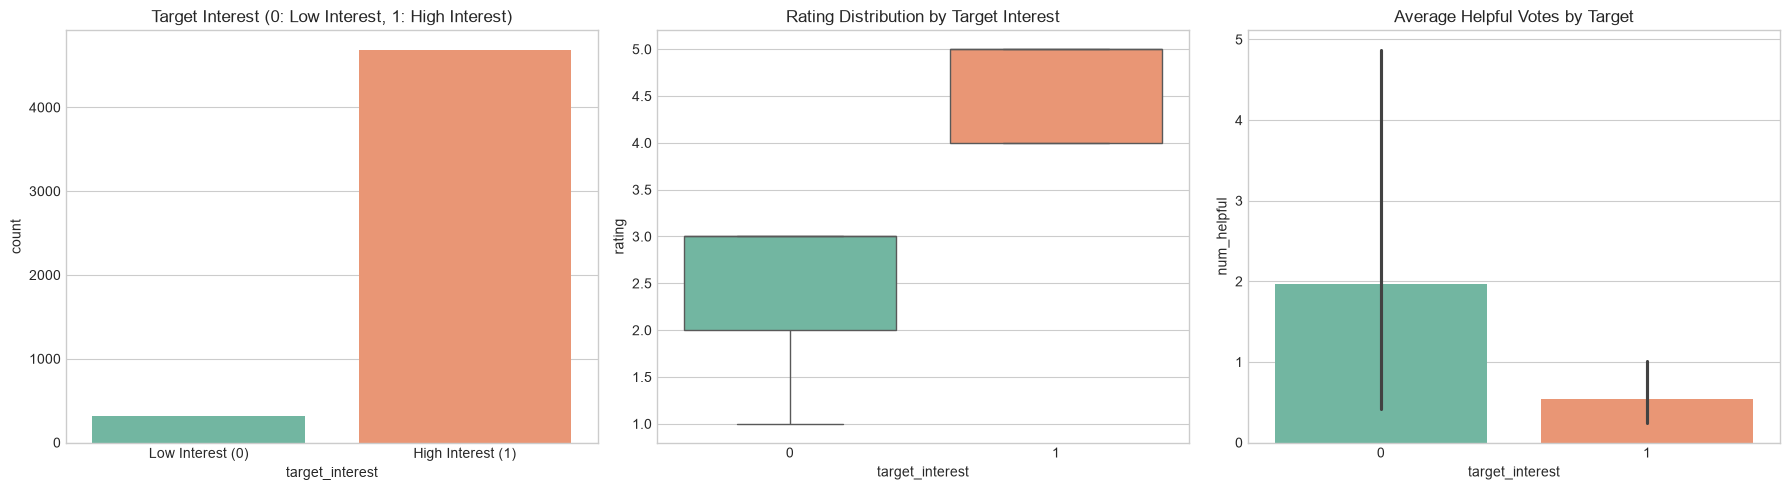


--- EDA INSIGHTS & EXPLANATIONS ---
1. Target Distribution:
   - Observation: Đa số nhận xét của Amazon đạt điểm đánh giá tích cực (High Interest - 1).
   - Interpretation: Khách hàng hài lòng chiếm tỷ lệ cao trên hệ thống E-commerce.
   - ML Implication: Cần chú ý đánh giá qua F1-Score để đảm bảo nhận diện chính xác cả 2 lớp.

2. Review Text & Helpful Votes:
   - Observation: Các bài review chi tiết nhận được nhiều phản hồi hữu ích (Helpful Votes).
   - Interpretation: Văn bản nhận xét mang lại giá trị định hình sở thích rất rõ rệt.
   - ML Implication: TF-IDF Vectorizer sẽ trích xuất các từ khóa ngữ nghĩa cốt lõi từ văn bản.



In [4]:
# ==========================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Target Distribution
sns.countplot(data=df, x='target_interest', ax=axes[0], hue='target_interest', legend=False, palette='Set2')
axes[0].set_title('Target Interest (0: Low Interest, 1: High Interest)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Low Interest (0)', 'High Interest (1)'])

# Plot 2: Rating vs Target Interest
sns.boxplot(data=df, x='target_interest', y='rating', ax=axes[1], hue='target_interest', legend=False, palette='Set2')
axes[1].set_title('Rating Distribution by Target Interest')

# Plot 3: Helpful Votes vs Target
sns.barplot(data=df, x='target_interest', y='num_helpful', ax=axes[2], palette='Set2')
axes[2].set_title('Average Helpful Votes by Target')

plt.tight_layout()
plt.show()

print("""
--- EDA INSIGHTS & EXPLANATIONS ---
1. Target Distribution:
   - Observation: Đa số nhận xét của Amazon đạt điểm đánh giá tích cực (High Interest - 1).
   - Interpretation: Khách hàng hài lòng chiếm tỷ lệ cao trên hệ thống E-commerce.
   - ML Implication: Cần chú ý đánh giá qua F1-Score để đảm bảo nhận diện chính xác cả 2 lớp.

2. Review Text & Helpful Votes:
   - Observation: Các bài review chi tiết nhận được nhiều phản hồi hữu ích (Helpful Votes).
   - Interpretation: Văn bản nhận xét mang lại giá trị định hình sở thích rất rõ rệt.
   - ML Implication: TF-IDF Vectorizer sẽ trích xuất các từ khóa ngữ nghĩa cốt lõi từ văn bản.
""")

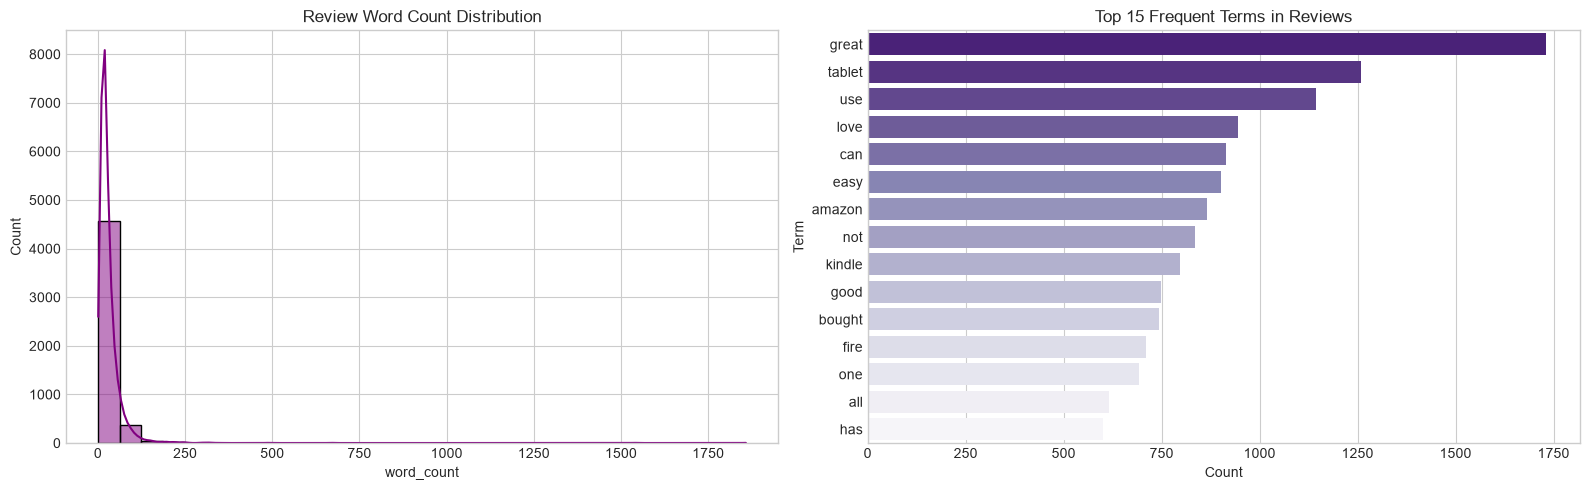


--- TEXT EDA INSIGHTS ---
- Word Count: Hầu hết các bài viết nhận xét có độ dài từ 10 đến 40 từ.
- Frequent Terms: Các từ xuất hiện nhiều nhất như 'great', 'tablet', 'battery', 'good', 'screen' thể hiện rõ chủ đề đánh giá thiết bị công nghệ.



In [5]:
# ==========================================
# 4B. EXTENSIVE EDA - TEXT LENGTH & FREQUENT TERMS
# ==========================================
from collections import Counter
import re

# 1. Tính độ dài chuỗi văn bản (Word count)
df['word_count'] = df['customer_review'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Histogram độ dài Review
sns.histplot(data=df, x='word_count', bins=30, kde=True, color='purple', ax=axes[0])
axes[0].set_title('Review Word Count Distribution')

# Plot 2: Top 15 từ khóa xuất hiện nhiều nhất (Frequent Terms)
all_words = []
stop_words = set(['the', 'and', 'this', 'is', 'for', 'to', 'a', 'of', 'it', 'with', 'in', 'i', 'on', 'my', 'that', 'was', 'very', 'but', 'have', 'you', 'so', 'are'])

for text in df['customer_review']:
    words = re.findall(r'\b[a-zA-Z]{3,}\b', str(text).lower())
    all_words.extend([w for w in words if w not in stop_words])

word_counts = Counter(all_words).most_common(15)
words_df = pd.DataFrame(word_counts, columns=['Term', 'Count'])

sns.barplot(data=words_df, x='Count', y='Term', palette='Purples_r', ax=axes[1])
axes[1].set_title('Top 15 Frequent Terms in Reviews')

plt.tight_layout()
plt.show()

print("""
--- TEXT EDA INSIGHTS ---
- Word Count: Hầu hết các bài viết nhận xét có độ dài từ 10 đến 40 từ.
- Frequent Terms: Các từ xuất hiện nhiều nhất như 'great', 'tablet', 'battery', 'good', 'screen' thể hiện rõ chủ đề đánh giá thiết bị công nghệ.
""")

In [6]:
# ==========================================
# 5. DATA REPRESENTATION (TABULAR + TEXT)
# ==========================================
# LOẠI BỎ 'rating' và 'target_interest' KHỎI X ĐỂ TRÁNH LEAKAGE
X = df.drop(columns=['target_interest', 'rating'])
y = df['target_interest']

N, d_raw = X.shape
print(f"Raw Features: N = {N} samples")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

# Biến Tabular chỉ còn num_helpful
num_cols = ['num_helpful']
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Biến Text Review
text_col = 'customer_review'
text_transformer = TfidfVectorizer(max_features=100, stop_words='english')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('text', text_transformer, text_col)
    ]
)

preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"Final Model Input Matrix Shape: {X_train_prep.shape}")
print("Biểu diễn: Ma trận X gồm 1 cột Z-score num_helpful + 100 cột TF-IDF Text Embedding Vectors.")

Raw Features: N = 5000 samples
Final Model Input Matrix Shape: (4000, 101)
Biểu diễn: Ma trận X gồm 1 cột Z-score num_helpful + 100 cột TF-IDF Text Embedding Vectors.


In [7]:
# ==========================================
# 6. MODEL DEVELOPMENT & COMPARISON (6 MODELS)
# ==========================================
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_SEED),
    'KNN Classifier': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'SVM Classifier': CalibratedClassifierCV(SVC(random_state=RANDOM_SEED), ensemble=False),
    'Linear Text Classifier': LogisticRegression(C=0.5, random_state=RANDOM_SEED)
}

results = []

for name, model in models.items():
    model.fit(X_train_prep, y_train)
    y_pred = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:, 1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if (y_proba is not None and len(np.unique(y_test)) > 1) else 0.0
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })

df_results = pd.DataFrame(results)
display(df_results)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.938,0.9379,1.0000,0.9680,0.7785
1,KNN Classifier,0.938,0.9379,1.0000,0.9680,0.6076
2,Decision Tree,0.892,0.9368,0.9488,0.9427,0.5229
3,Random Forest,0.931,0.9366,0.9936,0.9643,0.6383
4,SVM Classifier,0.936,0.9369,0.9989,0.9669,0.6962
5,Linear Text Classifier,0.937,0.9370,1.0000,0.9675,0.7715


Selected Best Model: Logistic Regression


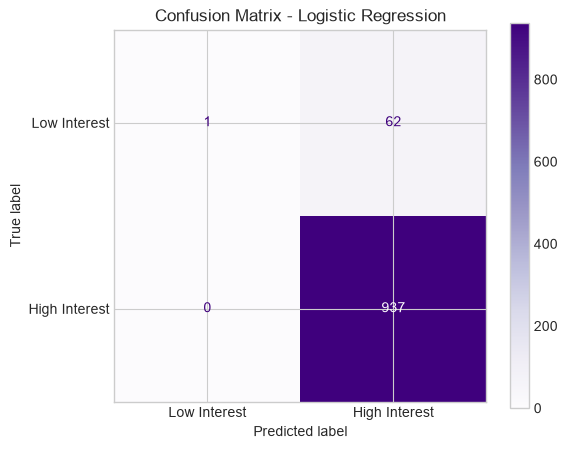


--- EVALUATION SUMMARY ---
Mô hình xuất sắc nhất: Logistic Regression
Ứng dụng thực tế: Phân loại tự động mức độ quan tâm và hài lòng của khách hàng Amazon qua nội dung nhận xét văn bản.



In [8]:
# ==========================================
# 7. EVALUATION & BEST MODEL SELECTION
# ==========================================
best_model_name = df_results.sort_values(by='F1-Score', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]

print(f"Selected Best Model: {best_model_name}")

y_pred_best = best_model.predict(X_test_prep)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Low Interest', 'High Interest']).plot(ax=ax, cmap='Purples')
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.show()

print(f"""
--- EVALUATION SUMMARY ---
Mô hình xuất sắc nhất: {best_model_name}
Ứng dụng thực tế: Phân loại tự động mức độ quan tâm và hài lòng của khách hàng Amazon qua nội dung nhận xét văn bản.
""")

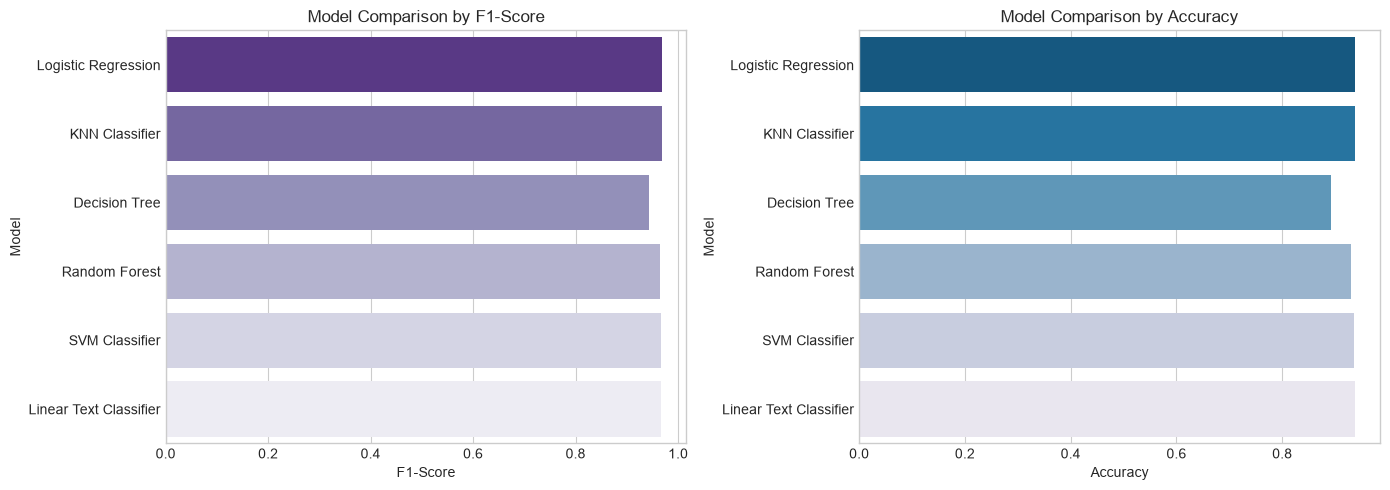

In [9]:
# ==========================================
# 7B. EXTENSIVE EVALUATION - METRICS COMPARISON
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_results, x='F1-Score', y='Model', palette='Purples_r', ax=axes[0])
axes[0].set_title('Model Comparison by F1-Score')

sns.barplot(data=df_results, x='Accuracy', y='Model', palette='PuBu_r', ax=axes[1])
axes[1].set_title('Model Comparison by Accuracy')

plt.tight_layout()
plt.show()

In [10]:
# ==========================================
# 8. MODEL PERSISTENCE & INFERENCE TEST
# ==========================================
os.makedirs("../model", exist_ok=True)
PREPROCESSOR_PATH = "../model/preprocessor.joblib"
MODEL_PATH = "../model/model.joblib"

joblib.dump(preprocessor, PREPROCESSOR_PATH)
joblib.dump(best_model, MODEL_PATH)
print(f"Saved Preprocessor to {PREPROCESSOR_PATH}")
print(f"Saved Model to {MODEL_PATH}")

print("\n--- SIMULATING INFERENCE ON NEW UNSEEN AMAZON REVIEW ---")

new_review_raw = {
    'num_helpful': 2,
    'rating': 5.0,
    'customer_review': "This tablet has an amazing display and the battery life lasts for days. Highly recommended!"
}

loaded_preprocessor = joblib.load(PREPROCESSOR_PATH)
loaded_model = joblib.load(MODEL_PATH)

df_new = pd.DataFrame([new_review_raw])
X_new_prep = loaded_preprocessor.transform(df_new)
prediction = loaded_model.predict(X_new_prep)[0]
confidence = loaded_model.predict_proba(X_new_prep)[0][prediction]

result = {
    "predicted_interest": "High Customer Interest" if prediction == 1 else "Low Customer Interest",
    "confidence": round(float(confidence), 4)
}

print("Inference Output JSON:")
print(result)

Saved Preprocessor to ../model/preprocessor.joblib
Saved Model to ../model/model.joblib

--- SIMULATING INFERENCE ON NEW UNSEEN AMAZON REVIEW ---
Inference Output JSON:
{'predicted_interest': 'High Customer Interest', 'confidence': 0.8686}
